# U-net for crack segmentation
### Assignment for M2MAS "Réseaux de Neurones profonds pour l'Apprentissage"

*References:*
 * U-Net: Convolutional Networks for Biomedical Image Segmentation, Olaf Ronneberger, Philipp Fischer, Thomas Brox, Medical Image Computing and Computer-Assisted Intervention (MICCAI), Springer, LNCS, Vol.9351: 234--241, 2015, available at [arXiv:1505.04597](http://arxiv.org/abs/1505.04597)
 * An 'All Terrain' Crack Detector Obtained by Deep Learning on Available Databases, Sébastien Drouyer, Image Processing On Line, 10 (2020), pp. 105–123. https://doi.org/10.5201/ipol.2020.282


### Modalities:
This assignment has to be send by email to bruno.galerne@univ-orleans.fr before Sunday March 1 2026, 23:59 with the name:

> ```NOM_PRENOM_M2MAS_202526_Unet_segmentation.ipynb```

Please use https://filesender.renater.fr/ if the file is larger than 5 MB.

Each question should be answered by providing a new section of the notebook (starting with a text cell ```# Question 1```) with all necessary code.
Code must be commented and introduced with a text cell. Results must be discussed in a text cell. In case of difficulty, you can also discuss errors in a text cell.


Each training of the neural network should be limited to 25 epochs. Note that the computation time will be arround 50 minutes on a T4 GPU.

### Questions:
First read and run the proposed notebook to get a first version of the network.

1. **Training pipeline:**
  
  1.A. **Dataset:** How many images are contained in each split (test, train, val)?

  Response :
  
  1.B. **Dataloarders:** What is done by the dataloader function for each split ? What are the sizes of the output images ? Explain why we restrict images to be mutiple of 32 in width and height.

  

  1.C. **Training loss:** Give the exact equation of what is computed by the line
  
  ```
  loss = criterion(outputs, masks)
  ```

  You should introduce notations for tensors and specify the size of the involved tensors.
  
  1.D. **Performance evaluation:** Explain (in a text cell) what is computed by

```
valscores = test_performance(unet, valset)
testscores = test_performance(unet, testset)
```

2. **First training with early stopping:**
  * Improve the proposed code by defining a ```train```function with the following capacity:
    * Train the model for given number of epochs (25 epochs, but use only 2 epochs while developing the code...).
    * At each epoch, evaluate the performance on the validation set and retain the network with the best F1 score on validation set.
    * At each epoch, print the running time, epoch loss and F1 score on validation set.
    * At the end of training plot both the epoch loss for each epoch and the F1 score on validation set for each epoch.
  * When calling the train function:
    * Save the trained model to disk and load the model from disk (see https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference)
    * Download the model parameters and/or save them to your google drive for a reference.
    * Reload this models as ```unet_ref``` and check the reload is OK.
    * Evaluate and report its performance scores using ```test_performance``` on the testset.

3. **Efficiency of Unet architecture:**
  * Define a class ```Unet_without_connection``` that is similar to the Unet architecture but does not contain skip connections between the first and second part of the architecture. Chose the layer parameters so that intermediate features have the same size as for the original ```Unet```.
  * Train an instance of ```Unet_without_connection``` and compare with ```unet_ref```.

4. **Training with data augmentation:**
  * Explain in a few sentences the concept and interest of data augmentation.
  * Discuss a data augmentation strategy for the proposed dataset and implement it within ```class CRACK500(Dataset):```
  * Retrain the U-net with data augmentation (starting from a random initialization) for 25 epochs.
  * Save and reload the model as ```unet_data_aug```.
  * Compare with ```unet_ref``` regarding training loss and performance on test set.


# Provided notebook (not to be changed)
*This whole section should not be changed (except for the dataloader).
You may copy and change cells into your sections.
You can suppose that the cells of the provided notebook have been executed before your answers (no need to copy everything, only the changes)*

## Check that the notebook has an active GPU:
(otherwise go to Edit->Notebook properties ->...)

In [ ]:
!nvidia-smi

Tue Mar  3 09:42:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Download CRACK500 datatset:
 * Reference work is here:
https://github.com/fyangneil/pavement-crack-detection

CRACK500

In [ ]:
# Images:
# traincrop.zip
!gdown 1jsCzT4uDkLHel8ov1CfbvLXiQVy6KExT
# testcrop.zip
!gdown 1NwyJjbhEATg-5x8-hQqet3KuiIZOhXZu
# valcrop.zip
!gdown 1DboG3vmTjbZyzrUQSyqToZw_xCOaeNoE
# Download .txt files describing datasets:
# train.txt
!gdown 1f6kco4VRf47bBp0qtb57sePvoqA_xFZa
# test.txt
!gdown 1He8W5Zf32rrA-pCAopfV-MrX94jKU4nR
# val.txt
!gdown 1f4FG4pmB7bcRLeSGtNVCpjgAaMD5mrdm

Downloading...
From (original): https://drive.google.com/uc?id=1jsCzT4uDkLHel8ov1CfbvLXiQVy6KExT
From (redirected): https://drive.google.com/uc?id=1jsCzT4uDkLHel8ov1CfbvLXiQVy6KExT&confirm=t&uuid=12205766-e3be-4067-946d-dd80610f3fdb
To: /content/traincrop.zip
100% 115M/115M [00:03<00:00, 37.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1NwyJjbhEATg-5x8-hQqet3KuiIZOhXZu
From (redirected): https://drive.google.com/uc?id=1NwyJjbhEATg-5x8-hQqet3KuiIZOhXZu&confirm=t&uuid=66b94464-306c-4d57-849e-bcba9126f6da
To: /content/testcrop.zip
100% 70.7M/70.7M [00:00<00:00, 136MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DboG3vmTjbZyzrUQSyqToZw_xCOaeNoE
To: /content/valcrop.zip
100% 20.8M/20.8M [00:00<00:00, 62.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1f6kco4VRf47bBp0qtb57sePvoqA_xFZa
To: /content/train.txt
100% 143k/143k [00:00<00:00, 4.41MB/s]
Downloading...
From: https://drive.google.com/uc?id=1He8W5Zf32rrA-pCAopfV-MrX94jKU4nR
To: /content/tes

Unzip data (-q=quietly):

In [ ]:
!unzip -q traincrop.zip
!unzip -q testcrop.zip
!unzip -q valcrop.zip
!ls

sample_data  testcrop.zip  traincrop	  train.txt  valcrop.zip
testcrop     test.txt	   traincrop.zip  valcrop    val.txt


In [ ]:
!ls traincrop|wc -l


3792


(640, 360)


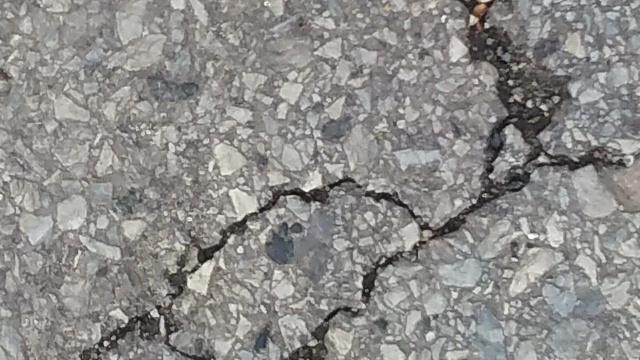

(640, 360)


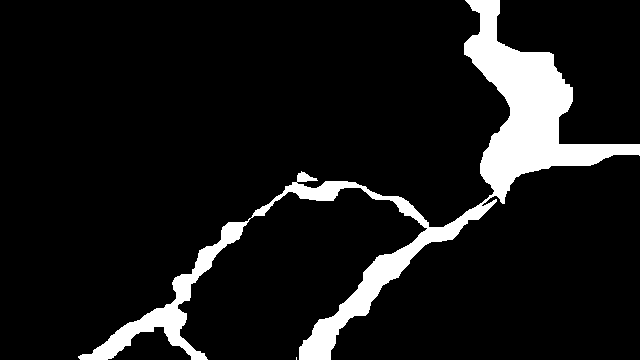

In [ ]:
# Example of data:
from PIL import Image

imgpath='traincrop/20160328_153714_1281_721.jpg'
imgpil = Image.open(imgpath)
print(imgpil.size)
display(imgpil)
imgpath='traincrop/20160328_153714_1281_721.png'
imgpil = Image.open(imgpath)
print(imgpil.size)
display(imgpil)

#PyTorch Dataloaders:

Create a data loader for the train, test, val datasets.
We follow mostly:
WRITING CUSTOM DATASETS, DATALOADERS AND TRANSFORMS
https://pytorch.org/tutorials/beginner/data_loading_tutorial.html


In [ ]:
import torch
from torchvision import transforms, utils
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import time

from PIL import Image
import torchvision.transforms.functional as TF
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# image lists are opened using panda:
trainlist = pd.read_csv('train.txt', sep=' ',header=None)
#print(trainlist)
print(trainlist.shape)
print(len(trainlist))
print(trainlist.iloc[1700,0]) # image filename
print(trainlist.iloc[1700,1]) # mask filename


(1896, 2)
1896
traincrop/20160405_171336_641_721.jpg
traincrop/20160405_171336_641_721.png


In [ ]:

class CRACK500(Dataset):
    """CRACK500 dataset."""

    def __init__(self, txt_file, root_dir, train=False, data_augmentation=False):
        """
        Args:
            txt_file (string): Path to the txt file list of image paths (eg train.txt, test.txt, val.txt).
            root_dir (string): Parent directory for the directory with all the images.
            train (boolean): True for training dataset (crop images to have size 256x256, otherwise get full image)
            data_augmentation (boolean): True for using data_augmentation during training
        """
        self.imgslist = pd.read_csv(txt_file, sep=' ',header=None)
        self.root_dir = root_dir
        self.train = train
        self.data_augmentation = data_augmentation
    def __len__(self):
        return len(self.imgslist)

    def __getitem__(self, idx):
        # get image and mask paths
        img_name = os.path.join(self.root_dir, self.imgslist.iloc[idx, 0])
        mask_name = os.path.join(self.root_dir, self.imgslist.iloc[idx, 1])

        # open images using PIL and apply transform list:
        image = Image.open(img_name)
        image = transforms.ToTensor()(image)  # conversion en tensor
        image = transforms.Grayscale()(image) #conversion en niveau gris
        if image.shape[1]>image.shape[2]:
          image = image.transpose(1,2)
        image = transforms.Normalize(0.5, 0.5)(image) # shape 1 x w x h

        # open mask binary image using PIL:
        mask = Image.open(mask_name)
        mask = transforms.ToTensor()(mask)
        if mask.shape[1]>mask.shape[2]:
          mask = mask.transpose(1,2)
        mask = mask.long().squeeze() # shape w x h

        if self.train: #get a subimage of size 256x256:
          if self.data_augmentation:

            # TODO:
            print('NOT IMPLEMENTED YET')

          else:
            # crop center 256x256:
            h,w = mask.shape
            c1 = (h-256)//2 # (c1,c2) is top-left corner
            c2 = (w-256)//2
            image = image[:,c1:(c1+256),c2:(c2+256)]
            mask = mask[c1:(c1+256),c2:(c2+256)]
        else:
          # full image cropped to be multiple of 32:
          h,w = mask.shape
          nh = (h//32)*32
          nw = (w//32)*32
          image = image[:,:nh,:nw]
          mask = mask[:nh,:nw]

        sample = [image, mask]
        return sample


## Test datasets:

train
torch.Size([1, 256, 256])
torch.float32
torch.Size([256, 256])
torch.int64


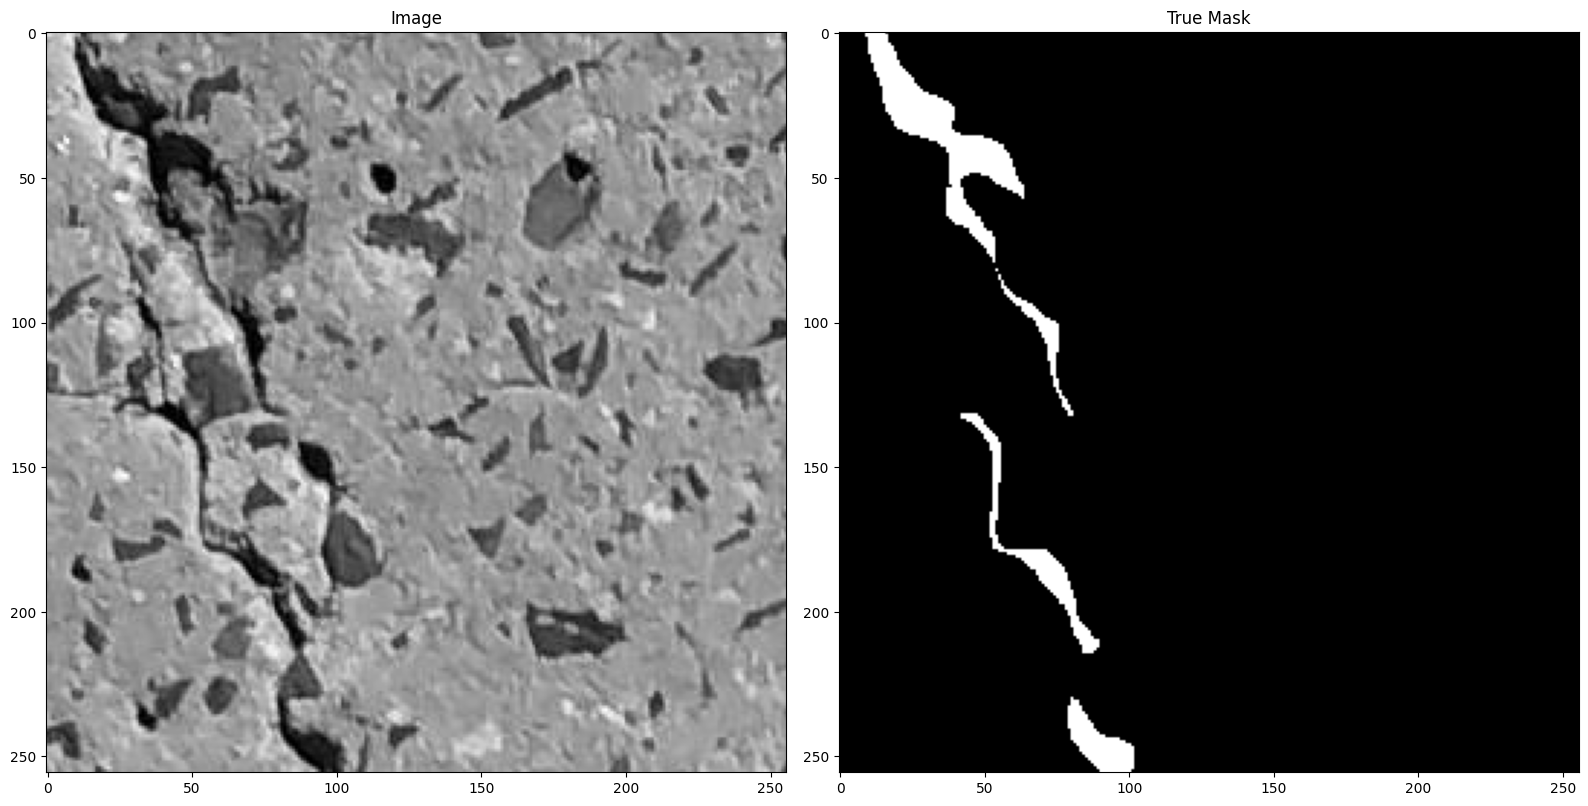

test
torch.Size([1, 352, 640])
torch.float32
torch.Size([352, 640])
torch.int64


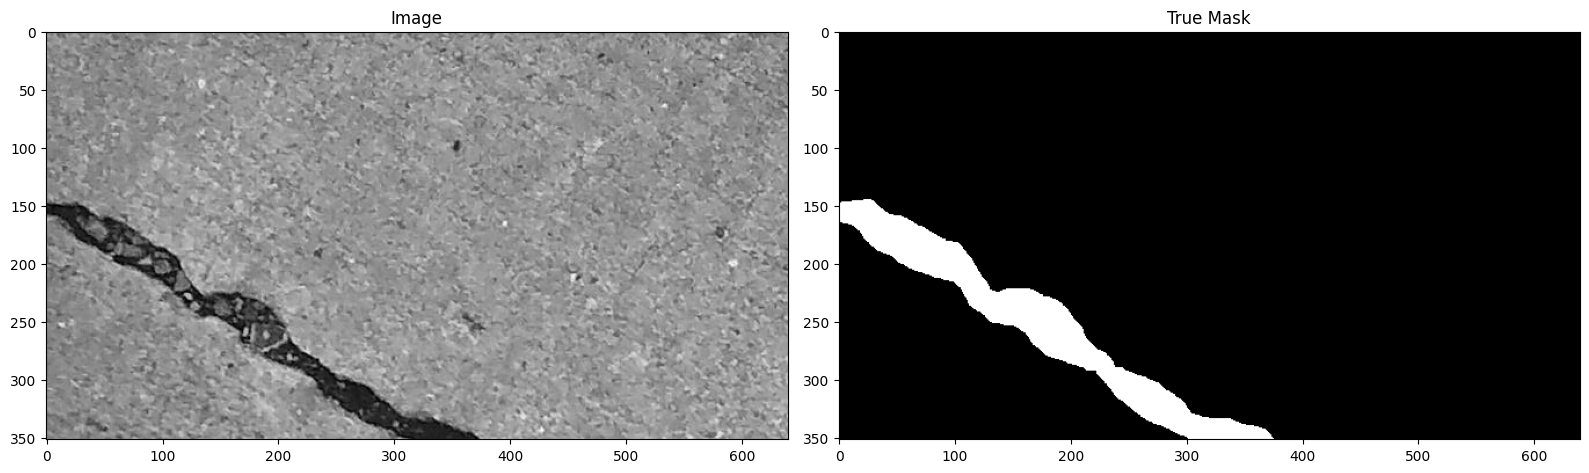

val
torch.Size([1, 352, 640])
torch.float32
torch.Size([352, 640])
torch.int64


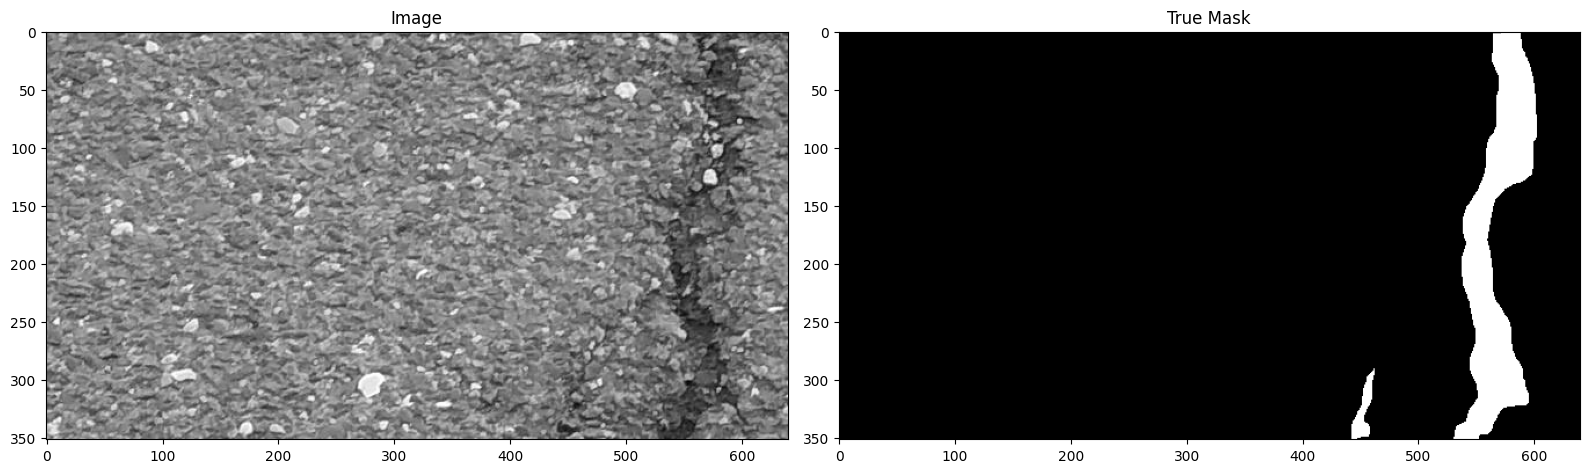

In [ ]:
trainset = CRACK500(txt_file='train.txt', root_dir='', train=True, data_augmentation=False)
image, mask = trainset[100]
print('train')
print(image.size())
print(image.dtype)
print(mask.size())
print(mask.dtype)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(image.squeeze(), cmap=plt.cm.gray)
ax[0].set_title("Image")
ax[1].imshow(mask, cmap=plt.cm.gray)
ax[1].set_title("True Mask")
fig.tight_layout()
plt.show()


testset = CRACK500(txt_file='test.txt', root_dir='', train=False, data_augmentation=False)
image, mask = testset[0]
print('test')
print(image.size())
print(image.dtype)
print(mask.size())
print(mask.dtype)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(image.squeeze(), cmap=plt.cm.gray)
ax[0].set_title("Image")
ax[1].imshow(mask, cmap=plt.cm.gray)
ax[1].set_title("True Mask")
fig.tight_layout()
plt.show()

valset = CRACK500(txt_file='val.txt', root_dir='', train=False, data_augmentation=False)
image, mask = valset[21]
print('val')
print(image.size())
print(image.dtype)
print(mask.size())
print(mask.dtype)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(image.squeeze(), cmap=plt.cm.gray)
ax[0].set_title("Image")
ax[1].imshow(mask, cmap=plt.cm.gray)
ax[1].set_title("True Mask")
fig.tight_layout()
plt.show()



In [ ]:
# check full dataset: (sanity check, useful only to check that all images are OK)
for k, dataset in enumerate([trainset, testset, valset]):
  print(['DATASET: ', k])
  for i in range(len(dataset)):
    image, mask = dataset[i]
    if k==0:
      if image.shape[1] != 256 or image.shape[2] != 256:
        print([k,i,image.shape])
    else:
      if image.shape[1] != 352 or image.shape[2] != 640:
        print([k,i,image.shape])

['DATASET: ', 0]
['DATASET: ', 1]
['DATASET: ', 2]
[2, 331, torch.Size([1, 480, 640])]
[2, 332, torch.Size([1, 480, 640])]
[2, 333, torch.Size([1, 480, 640])]
[2, 334, torch.Size([1, 480, 640])]
[2, 335, torch.Size([1, 480, 640])]
[2, 336, torch.Size([1, 480, 640])]
[2, 337, torch.Size([1, 480, 640])]
[2, 338, torch.Size([1, 480, 640])]
[2, 339, torch.Size([1, 480, 640])]
[2, 340, torch.Size([1, 480, 640])]
[2, 341, torch.Size([1, 480, 640])]
[2, 342, torch.Size([1, 480, 640])]
[2, 343, torch.Size([1, 480, 640])]
[2, 344, torch.Size([1, 480, 640])]
[2, 345, torch.Size([1, 480, 640])]
[2, 346, torch.Size([1, 480, 640])]
[2, 347, torch.Size([1, 480, 640])]


## U-net version with same size (as in IPOL paper)


In [ ]:
#double 3x3 convolution
def dual_conv(in_channel, out_channel):
    conv = nn.Sequential(
        nn.Conv2d(in_channel, out_channel, kernel_size=3,padding=1,padding_mode='reflect'),
        nn.ReLU(inplace= True),
        nn.Conv2d(out_channel, out_channel, kernel_size=3,padding=1,padding_mode='reflect'),
        nn.ReLU(inplace= True),
    )
    return conv

class Unet(nn.Module):
    def __init__(self):
        super(Unet, self).__init__()

        # Left side (contracting path)
        self.dwn_conv1 = dual_conv(1, 64)
        self.dwn_conv2 = dual_conv(64, 128)
        self.dwn_conv3 = dual_conv(128, 256)
        self.dwn_conv4 = dual_conv(256, 512)
        self.dwn_conv5 = dual_conv(512, 1024)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        #Right side  (expnsion path)
        #transpose convolution is used shown as green arrow in architecture image
        self.trans1 = nn.ConvTranspose2d(1024,512, kernel_size=2, stride= 2)
        self.up_conv1 = dual_conv(1024,512)
        self.trans2 = nn.ConvTranspose2d(512,256, kernel_size=2, stride= 2)
        self.up_conv2 = dual_conv(512,256)
        self.trans3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride= 2)
        self.up_conv3 = dual_conv(256,128)
        self.trans4 = nn.ConvTranspose2d(128,64, kernel_size=2, stride= 2)
        self.up_conv4 = dual_conv(128,64)

        #output layer
        self.out = nn.Conv2d(64, 2, kernel_size=1)

    def forward(self, image):

        #forward pass for Left side
        x1 = self.dwn_conv1(image)
        x2 = self.maxpool(x1)
        x3 = self.dwn_conv2(x2)
        x4 = self.maxpool(x3)
        x5 = self.dwn_conv3(x4)
        x6 = self.maxpool(x5)
        x7 = self.dwn_conv4(x6)
        x8 = self.maxpool(x7)
        x9 = self.dwn_conv5(x8)

        #forward pass for Right side
        x = self.trans1(x9)
        x = self.up_conv1(torch.cat([x,x7], 1))

        x = self.trans2(x)
        x = self.up_conv2(torch.cat([x,x5], 1))

        x = self.trans3(x)
        x = self.up_conv3(torch.cat([x,x3], 1))

        x = self.trans4(x)
        x = self.up_conv4(torch.cat([x,x1], 1))

        x = self.out(x)

        return x

unet = Unet().to(device)


## Test of untrained Unet:

In [ ]:
# Apply Unet and check sizes:
image, mask = trainset[3]
with torch.no_grad():
  out=unet(torch.unsqueeze(image.to(device),0))
  print('output size: ', out.size())
  print('mask size: ',mask.size())
  criterion = nn.CrossEntropyLoss()
  loss = criterion(out, torch.unsqueeze(mask.to(device),0))
  print(loss.item())

output size:  torch.Size([1, 2, 256, 256])
mask size:  torch.Size([256, 256])
0.6829255819320679


#Training of Unet:


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(unet.parameters())


##Define data loader for batch training:

In [ ]:
dataloader = DataLoader(trainset, batch_size=20, shuffle=True, num_workers=2)
n_train = len(trainset)

In [ ]:
iter_info = 100
since = time.time()
for epoch in range(2):
  since_epoch = time.time()
  running_loss = 0.0
  epoch_loss = 0.0
  for i, data in enumerate(dataloader, 0):
    # get the inputs; data is a list of [inputs, labels]
    images = data[0].to(device)
    masks = data[1].to(device)

    # zero the parameter gradients
    optimizer.zero_grad()

    # forward + backward + optimize
    outputs = unet(images)
    loss = criterion(outputs, masks)
    loss.backward()
    optimizer.step()

    # print statistics
    running_loss += loss.item()
    epoch_loss += loss.item()
    if i % iter_info == (iter_info-1):    # print every iter_info mini-batches
      print('[%d, %5d] loss: %.3f' %
        (epoch + 1, i + 1, running_loss / iter_info))
      running_loss = 0.0
  time_elapsed_epoch = time.time() - since_epoch
  print('Epoch completed in {:.0f}m {:.0f}s'.format(
        time_elapsed_epoch // 60, time_elapsed_epoch % 60))
  print('Epoch loss: %.3f' % (epoch_loss / n_train))

print('Finished Training')
time_elapsed = time.time() - since
print('Training completed in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))


Epoch completed in 1m 44s
Epoch loss: 0.019
Epoch completed in 1m 49s
Epoch loss: 0.008
Finished Training
Training completed in 3m 33s


#Visualize some prediction (on cropped val image to be improved for performance evaluation):
Images size must be multiple of 32.






torch.Size([1, 352, 640]) torch.Size([352, 640])
torch.Size([1, 352, 640]) torch.Size([352, 640])


<Figure size 640x480 with 0 Axes>

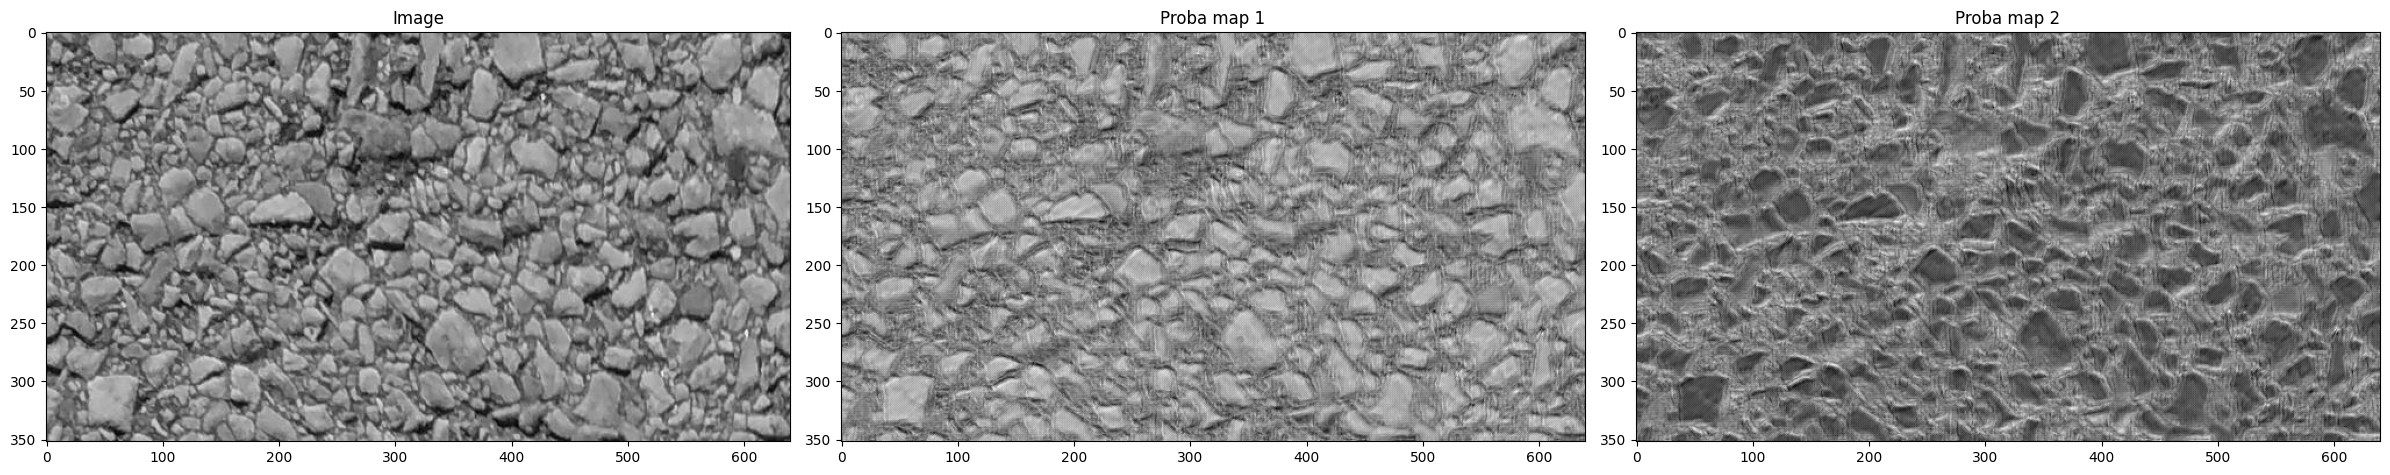

<Figure size 640x480 with 0 Axes>

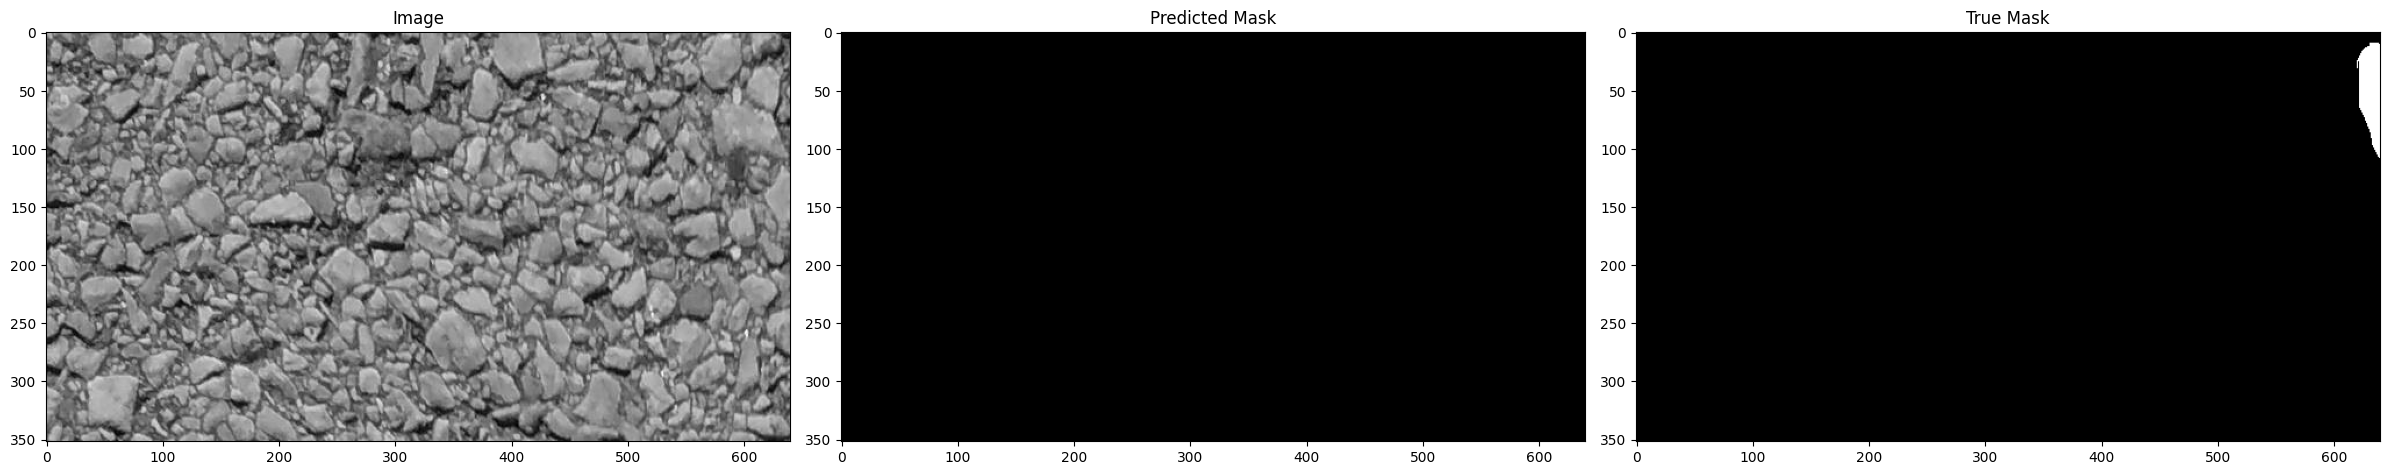

In [ ]:

i = np.random.randint(len(valset))
image, mask = valset[i]
print(image.size(), mask.size())
h,w = mask.size()
nh = (h//32)*32
nw = (w//32)*32
image = image[:,:nh,:nw]
mask = mask[:nh,:nw]
print(image.size(), mask.size())

with torch.no_grad():
  out = unet(torch.unsqueeze(image.to(device),0))
  predprob = F.softmax(out,dim=1).to('cpu')
predprob1 = predprob[0,0,:,:].squeeze()
predprob2 = predprob[0,1,:,:].squeeze()
predmask = torch.argmax(out.squeeze(), dim=0).to('cpu')

plt.figure();

fig, ax = plt.subplots(1, 3, figsize=(24, 8))
ax[0].imshow(image.squeeze(), cmap=plt.cm.gray)
ax[0].set_title("Image")
ax[1].imshow(predprob1, cmap=plt.cm.gray)
ax[1].set_title("Proba map 1")
ax[2].imshow(predprob2, cmap=plt.cm.gray)
ax[2].set_title("Proba map 2")
fig.tight_layout()
plt.show();

plt.figure()

fig, ax = plt.subplots(1, 3, figsize=(24, 8))
ax[0].imshow(image.squeeze(), cmap=plt.cm.gray)
ax[0].set_title("Image")
ax[1].imshow(predmask, cmap=plt.cm.gray)
ax[1].set_title("Predicted Mask")
ax[2].imshow(mask, cmap=plt.cm.gray)
ax[2].set_title("True Mask")
fig.tight_layout()
plt.show();



## Performance evaluation:

In [ ]:
def test_performance(unet, dataset):
  tp_count = 0
  tn_count = 0
  fp_count = 0
  fn_count = 0
  with torch.no_grad():
    for i, data in enumerate(dataset):
      image = data[0]
      mask = data[1]
      h,w = mask.size()
      nh = (h//32)*32
      nw = (w//32)*32
      image = image[:,:nh,:nw].to(device)
      mask = mask[:nh,:nw].to(device)
      out = unet(torch.unsqueeze(image,0))
      predmask = torch.argmax(out.squeeze(), dim=0)
      # count:
      tp = torch.sum(predmask*mask)
      fp = torch.sum(predmask*(1.-mask))
      tn = torch.sum((1-predmask)*(1.-mask))
      fn = torch.sum((1-predmask)*mask)
      if not (tp+fp+tn+fn == nh*nw):
        print('counting inconstancy')
      tp_count = tp_count + tp
      tn_count = tn_count + tn
      fp_count = fp_count + fp
      fn_count = fn_count + fn
      if i%100==99:
        print('test_performance: Image ', i, ' / ', len(dataset))
    print(tp_count.item(), tn_count.item(), fp_count.item(), fn_count.item())
    precision = (tp_count/(tp_count+fp_count)).to('cpu').item()
    recall = (tp_count/(tp_count+fn_count)).to('cpu').item()
    F1score =  2. * precision * recall / (precision + recall)
    return([precision, recall, F1score])

In [ ]:


valscores = test_performance(unet, valset)
for name, val in zip(["precision", "recall", "F1score"], valscores):
  print(name, '{:.4f}'.format(val))

test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
0 75278680.0 0.0 4511360
precision nan
recall 0.0000
F1score nan


#Question 1
TODO

In [ ]:
print(len(trainset),len(testset),len(valset))

1896 1124 348


- R1.A  

      le train dataset a 1896 images  
      le test dataset a 1124 images  
      le validation dataset a 348 images



- R1.B  
    ##### Dataloader
      Le dataloader charge les images et masques via la classe CRACK500,
      regroupe les données en mini-batch,
      mélange les données si shuffle=True,
      retourne des tenseurs prêts à être envoyés au GPU .
    ##### Tailles des images en sortie

      Dans le reseau CRACK500, on a :
      # crop center 256x256, donc les dimensions de sortie sont:
      Image : (1, 256, 256)
      Mask : (256, 256)
      Avec batch_size = 20 :
      Images : (20, 1, 256, 256)
      Masks : (20, 256, 256)

      Et pour Validation & Test sets, on a :
      # full image cropped to be multiple of 32
      nh = (h//32)*32
      nw = (w//32)*32  
      donc la taille finale est :
      images(1, 352, 640)
      Mask : (352, 640)  

    ##### Pourquoi la taille de l'image doit être 32*32 ?
      Pour eviter des erreurs de concatenation et d'incompatibilité de dimension pendant le skip connection.

- R1.C

  
  ### Notations

  Les outputs sont  :

    $$\mathbf{O} \in \mathbb{R}^{B \times 2 \times H \times W}$$

  avec
  - $B$ : la taille du batch,
  - $c:2$ : le numero de la classe,
  - $H, W$ : la hauteur et la largeur,
  - $O_{b,c,i,j}$ : le logit predit pour la classe  $c$ sur le pixel $(i,j)$ de l'image $b$.


  Et les masks sont :

    $$\mathbf{Y} \in \({0,1\})^{B \times H \times W}$$

    avec  $Y_{b,i,j}$ le vrai label du pixel $(i,j)$.

  ### Softmax pixel par pixel


Pour chaque pixel $(i,j)$ de l’image $b$, la probabilité prédite pour la classe $c$ est donnée par la fonction softmax :

$$
p_{b,c,i,j}
=
\frac{\exp(O_{b,c,i,j})}
{\sum_{k=1}^{2} \exp(O_{b,k,i,j})}
$$

où :
  - $O_{b,c,i,j}$ est le score (logit) prédit par le réseau,
  - $p_{b,c,i,j}$ est la probabilité associée à la classe $c$,
  - la somme des probabilités sur les deux classes vaut 1 :

  $$
  \sum_{c=1}^{2} p_{b,c,i,j} = 1
  $$


  ### Fonction de perte : entropie croisée

La fonction de perte utilisée est l’entropie croisée moyenne sur tous les pixels du batch :

$$
\mathcal{L}
=
-\frac{1}{BHW}
\sum_{b=1}^{B}
\sum_{i=1}^{H}
\sum_{j=1}^{W}
\log \left( p_{b,\,Y_{b,i,j},\,i,j} \right)
$$

où :
- $B$ est la taille du batch,
- $H$ et $W$ sont la hauteur et la largeur des images,
- $Y_{b,i,j}$ est la vraie classe du pixel $(i,j)$,
- $p_{b,\,Y_{b,i,j},\,i,j}$ est la probabilité prédite pour la vraie classe.

Cette perte mesure à quel point les probabilités prédites sont proches des labels réels, pixel par pixel.

- R1.D  
valscore et testscore mesurent la performance sur la validation et le test en calculant :  

  la precision : le nombre de pixels prédits fissure correct,  
  le recall : Parmi les vraies fissures, combien sont détectées,      
  le F1-score : Compromis entre précision et rappel.  
    Et les metriques sont calculées au niveau pixel.


#Question 2
## First training with early stopping:

Le terme early stopping mentionné dans l’intitulé m’a initialement conduit à envisager l’implémentation d’un mécanisme d’arrêt anticipé basé sur une absence d’amélioration des performances de validation pendant un certain nombre d’epochs (patience). Cependant, la description de la consigne ne précisait pas explicitement ce critère d’arrêt. Par conséquent, l’entraînement a été effectué sur l’ensemble des 25 epochs, tout en conservant le modèle correspondant au meilleur F1-score sur l’ensemble de validation.

- Training function.

In [ ]:


import copy
import time

def train_model(model, trainloader, valset, criterion, optimizer, num_epochs=25):

    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0

    epoch_losses = []
    val_f1_scores = []

    since = time.time()

    for epoch in range(num_epochs):

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        epoch_start = time.time()

        # Entrainement
        model.train()
        running_loss = 0.0

        for images, masks in trainloader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        epoch_losses.append(epoch_loss)

        # Validation
        model.eval()
        valscores = test_performance(model, valset)
        val_precision, val_recall, val_f1 = valscores
        val_f1_scores.append(val_f1)

        # Keep best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())

        epoch_time = time.time() - epoch_start

        print(f"Loss: {epoch_loss:.4f}")
        print(f"Validation F1: {val_f1:.4f}")
        print(f"Epoch time: {epoch_time:.0f}s")

    total_time = time.time() - since
    print(f"\nTraining completed in {total_time/60:.1f} minutes")
    print(f"Best Validation F1: {best_f1:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)

    return model, epoch_losses, val_f1_scores

- Training


In [ ]:
unet = Unet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)

trainloader = DataLoader(trainset, batch_size=20, shuffle=True)

unet, losses, f1_scores = train_model(
    unet,
    trainloader,
    valset,
    criterion,
    optimizer,
    num_epochs= 25 # à mettre au final
)


Epoch 1/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
1290329 74979536.0 299209.0 3221031
Loss: 0.2738
Validation F1: 0.4230
Epoch time: 155s

Epoch 2/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
2465244 73959984.0 1318774.0 2046116
Loss: 0.1315
Validation F1: 0.5944
Epoch time: 162s

Epoch 3/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
2243811 74359968.0 918766.0 2267549
Loss: 0.1216
Validation F1: 0.5848
Epoch time: 162s

Epoch 4/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
2474430 74450144.0 828580.0 2036930
Loss: 0.1179
Validation F1: 0.6333
Epoch time: 159s

Epoch 5/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
3070379 73950664.0 1328050.0 1440981


Les résultats indiquent que le meilleur modèle est obtenu à la 23 ème epoch d’entraînement (Validation F1 = 0.7697).

- Save the model on my drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(unet.state_dict(), "/content/drive/MyDrive/best_unet.pth")

Mounted at /content/drive


- Reload the model from the drive

In [ ]:

unet_ref = Unet().to(device)
unet_ref.load_state_dict(torch.load("/content/drive/MyDrive/best_unet.pth"))
unet_ref.eval()


Mounted at /content/drive


Unet(
  (dwn_conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inpla

Voici le modèle correspondant au meilleur score F1 obtenu sur le jeu de validation.

- Evaluation on test set

In [ ]:
testscores = test_performance(unet_ref, testset)

for name, val in zip(["precision", "recall", "F1score"], testscores):
    print(name, f"{val:.4f}")

test_performance: Image  99  /  1124
test_performance: Image  199  /  1124
test_performance: Image  299  /  1124
test_performance: Image  399  /  1124
test_performance: Image  499  /  1124
test_performance: Image  599  /  1124
test_performance: Image  699  /  1124
test_performance: Image  799  /  1124
test_performance: Image  899  /  1124
test_performance: Image  999  /  1124
test_performance: Image  1099  /  1124
9999117 232311136.0 6740017.0 4164368
precision 0.5973
recall 0.7060
F1score 0.6471


Parmi les pixels prédits comme fissures, environ 60 % sont réellement des fissures (bonne précision). Et le modèle détecte environ 71 % des fissures réelles, ce qui indique aussi un bon recall. Le score F1 global est d’environ 0.65, ce qui montre que les performances restent modérées. Cette situation peut s’expliquer peu être par un déséquilibre des classes : les pixels de fond (blancs) sont beaucoup plus nombreux que les pixels correspondant aux fissures dans les images d’entraînement. Le modèle a donc tendance à prédire majoritairement le fond, ce qui réduit sa capacité à détecter toutes les fissures.

- Plot loss and F1

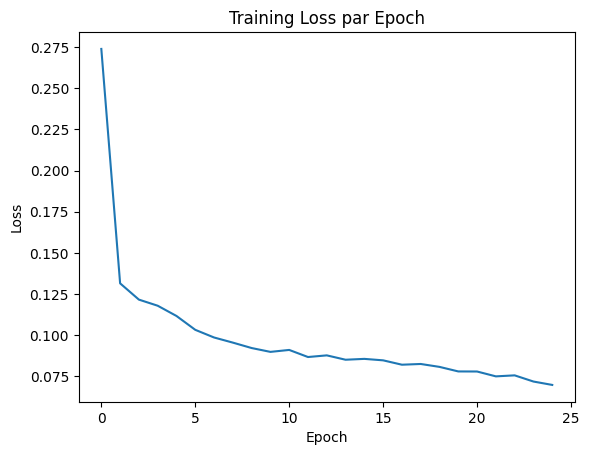

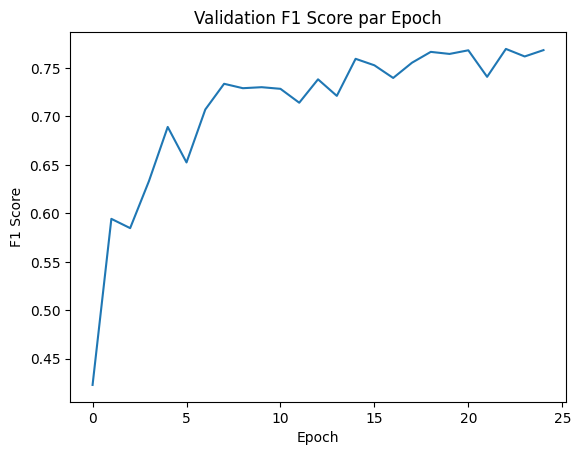

In [ ]:
plt.figure()
plt.plot(losses)
plt.title("Training Loss par Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(f1_scores)
plt.title("Validation F1 Score par Epoch")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.show()

Le premier graphique montre une diminution brutale de la loss entre la première et la deuxième epoch, suivie d’une décroissance progressive jusqu’à atteindre sa valeur minimale lors de la dernière epoch d’entraînement.

Le second graphique met en évidence une augmentation marquée du F1-score entre la première et la deuxième epoch. Par la suite, on observe une évolution en dents de scie, mais avec une tendance globale croissante.

On peut en déduire que le modèle apprend rapidement au cours des premières epochs, puis continue à améliorer progressivement ses performances de segmentation.

#Question 3
### Efficiency of Unet architecture:

- Architecture of Unet without connection

In [ ]:
# Unet sans torch.cat([x, skip], dim=1), et donc le nombre de canal d'entré dans dual_conv ne
#  sera plus le double de la sortie de  ConvTranspose2ddans le rigth side
class Unet_without_connection(nn.Module):
    def __init__(self):
        super(Unet_without_connection, self).__init__()

        # Left side (contracting path)
        self.dwn_conv1 = dual_conv(1, 64)
        self.dwn_conv2 = dual_conv(64, 128)
        self.dwn_conv3 = dual_conv(128, 256)
        self.dwn_conv4 = dual_conv(256, 512)
        self.dwn_conv5 = dual_conv(512, 1024)

        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        #Right side (expnsion path)
        #transpose convolution is used shown as green arrow in architecture image
        self.trans1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = dual_conv(512, 512)

        self.trans2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = dual_conv(256, 256)

        self.trans3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = dual_conv(128, 128)

        self.trans4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = dual_conv(64, 64)

        #output layer
        self.out = nn.Conv2d(64, 2, kernel_size=1)

    def forward(self, image):

        #forward pass for Left side
        x1 = self.dwn_conv1(image)
        x2 = self.maxpool(x1)

        x3 = self.dwn_conv2(x2)
        x4 = self.maxpool(x3)

        x5 = self.dwn_conv3(x4)
        x6 = self.maxpool(x5)

        x7 = self.dwn_conv4(x6)
        x8 = self.maxpool(x7)

        x9 = self.dwn_conv5(x8)

        #forward pass for Right side
        x = self.trans1(x9)
        x = self.up_conv1(x)

        x = self.trans2(x)
        x = self.up_conv2(x)

        x = self.trans3(x)
        x = self.up_conv3(x)

        x = self.trans4(x)
        x = self.up_conv4(x)

        x = self.out(x)

        return x

- Training function

In [ ]:

def train_model(model, trainloader, valset, criterion, optimizer, num_epochs=25):

    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0

    epoch_losses = []
    val_f1_scores = []

    since = time.time()

    for epoch in range(num_epochs):

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        epoch_start = time.time()

        # Training
        model.train()
        running_loss = 0.0

        for images, masks in trainloader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        epoch_losses.append(epoch_loss)

      # Validation
        model.eval()
        with torch.no_grad():
            precision, recall, val_f1 = test_performance(model, valset)

        val_f1_scores.append(val_f1)

        # save of the best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())

        epoch_time = time.time() - epoch_start

        print(f"Loss: {epoch_loss:.4f}")
        print(f"Validation F1: {val_f1:.4f}")
        print(f"Epoch time: {epoch_time:.0f}s")

    total_time = time.time() - since

    print(f"\nTraining completed in {total_time/60:.1f} minutes")
    print(f"Best Validation F1: {best_f1:.4f}")

    # Load best weights
    model.load_state_dict(best_model_wts)

    return model, epoch_losses, val_f1_scores

- Training

In [ ]:
# Initialisation
model_no_skip = Unet_without_connection().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_no_skip.parameters(), lr=1e-4)

trainloader = DataLoader(trainset, batch_size=20, shuffle=True)

# Training
model_no_skip, losses_no_skip, f1_no_skip = train_model(
    model_no_skip,
    trainloader,
    valset,
    criterion,
    optimizer,
    num_epochs=25 # à faire finalement
)


Epoch 1/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
0 75278680.0 0.0 4511360
Loss: 0.3314
Validation F1: nan
Epoch time: 132s

Epoch 2/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
2335093 74244312.0 1034420.0 2176267
Loss: 0.1337
Validation F1: 0.5926
Epoch time: 135s

Epoch 3/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
1814979 74783608.0 495108.0 2696381
Loss: 0.1271
Validation F1: 0.5321
Epoch time: 134s

Epoch 4/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
2676415 73880592.0 1398139.0 1834945
Loss: 0.1261
Validation F1: 0.6234
Epoch time: 133s

Epoch 5/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
1636709 74959632.0 319076.0 2874651
Loss: 0.1176
V

Ici le meilleur modèle a été obtenu un peut  tôt, au 21ème epoch de l'entrainement avec un score interessant.

Les résultats montrent que les deux architectures(avec skip connection et sans skip connection ) obtiennent des performances comparables en termes de F1-score(0.7697 & 0.7720 ) de validation. Bien que le modèle avec skip connections présente une loss légèrement plus faible, l’amélioration du F1-score reste marginale. Par ailleurs, le modèle sans connexions est plus rapide à entraîner. Ces observations suggèrent que, dans ce contexte expérimental, l’apport des skip connections reste limité.

- Save of parameters of the best model on my drive

In [ ]:

torch.save(model_no_skip.state_dict(), "/content/drive/MyDrive/best_no_skip.pth")

Mounted at /content/drive


- Reload of best model

In [ ]:
model_no_skip_best = Unet_without_connection().to(device)
model_no_skip_best.load_state_dict(torch.load("/content/drive/MyDrive/best_no_skip.pth"))
model_no_skip_best.eval()

Unet_without_connection(
  (dwn_conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)


- comparison of Unet with connection and without connection

In [ ]:
scores_ref = test_performance(unet_ref, testset)
for name, val in zip(["precision", "recall", "F1score"], scores_ref):
    print(name, f"{val:.4f}")

scores_no_skip = test_performance(model_no_skip_best, testset)
for name, val in zip(["precision", "recall", "F1score"], scores_no_skip):
    print(name, f"{val:.4f}")


test_performance: Image  99  /  1124
test_performance: Image  199  /  1124
test_performance: Image  299  /  1124
test_performance: Image  399  /  1124
test_performance: Image  499  /  1124
test_performance: Image  599  /  1124
test_performance: Image  699  /  1124
test_performance: Image  799  /  1124
test_performance: Image  899  /  1124
test_performance: Image  999  /  1124
test_performance: Image  1099  /  1124
9999117 232311136.0 6740017.0 4164368
precision 0.5973
recall 0.7060
F1score 0.6471
test_performance: Image  99  /  1124
test_performance: Image  199  /  1124
test_performance: Image  299  /  1124
test_performance: Image  399  /  1124
test_performance: Image  499  /  1124
test_performance: Image  599  /  1124
test_performance: Image  699  /  1124
test_performance: Image  799  /  1124
test_performance: Image  899  /  1124
test_performance: Image  999  /  1124
test_performance: Image  1099  /  1124
9565347 233969536.0 5081506.0 4598138
precision 0.6531
recall 0.6754
F1score 0.6

### Commentaire :
 Les résultats obtenus sur l’ensemble de test montrent que le modèle sans connections atteint un F1-score légèrement supérieur (0.6640) à U-Net avvec skip connection (0.6471).  
 Bien que le modèle avec skip connections présente un recall plus élevé, indiquant une meilleure capacité à détecter les fissures, il souffre d’une précision plus faible .


Théoriquement, le modèle obtenu par l'entrainement sur U-net avec connection est censé être plus performant, ce qui n'est pas notre cas.  Cette non concordance peut être causée par la nature déséquilibré du nombre des pixels fissurée et non fissurés de notre jeux de données, ou d'autres paramètres à etudiés.

#Question 4
### Training with data augmentation:

- Explaining :   
La data augmentation consiste à appliquer des transformations aléatoires aux images d’entraînement afin de créer de nouvelles variations des données existantes.  

 - Discussion :   
 Dans notre cas, chaque couple image-masque doit subir la même transformation afin de garder les même labels.
 Exemple de transformation : rotation suivant un angle, flip horizontal ou vertical, recadrage et variations de la luminosité(ceci peut se faire uniquement sur l'image) .



- Implementation dans la classe CRACK500

Augmentation uniquement sur le trainset

In [ ]:
import random

class CRACK500(Dataset):
    """CRACK500 dataset."""

    def __init__(self, txt_file, root_dir, train=False, data_augmentation=False):
        """
        Args:
            txt_file (string): Path to the txt file list of image paths (eg train.txt, test.txt, val.txt).
            root_dir (string): Parent directory for the directory with all the images.
            train (boolean): True for training dataset (crop images to have size 256x256, otherwise get full image)
            data_augmentation (boolean): True for using data_augmentation during training
        """
        self.imgslist = pd.read_csv(txt_file, sep=' ',header=None)
        self.root_dir = root_dir
        self.train = train
        self.data_augmentation = data_augmentation

    def __len__(self):
        return len(self.imgslist)

    def __getitem__(self, idx):

        # get image and mask paths
        img_name = os.path.join(self.root_dir, self.imgslist.iloc[idx, 0])
        mask_name = os.path.join(self.root_dir, self.imgslist.iloc[idx, 1])

        # open images using PIL and apply transform list:
        image = Image.open(img_name)
        image = transforms.ToTensor()(image)  # conversion en tensor
        image = transforms.Grayscale()(image) #conversion en niveau gris
        if image.shape[1]>image.shape[2]:
            image = image.transpose(1,2)
        image = transforms.Normalize(0.5, 0.5)(image) # shape 1 x w x h

        # open mask binary image using PIL:
        mask = Image.open(mask_name)
        mask = transforms.ToTensor()(mask)
        if mask.shape[1]>mask.shape[2]:
            mask = mask.transpose(1,2)
        mask = mask.long().squeeze() # shape w x h

        if self.train: #get a subimage of size 256x256:
            if self.data_augmentation:

                # Random horizontal flip
                if random.random() > 0.5:
                    image = torch.flip(image, dims=[2])
                    mask = torch.flip(mask, dims=[1])

                # Small random rotation (±10 degrees)
                angle = random.uniform(-10, 10)
                image = transforms.functional.rotate(image, angle)
                mask = transforms.functional.rotate(mask.unsqueeze(0).float(), angle)
                mask = mask.squeeze().long()

                # Random crop 256x256
                h,w = mask.shape
                if h > 256 and w > 256:
                    top = random.randint(0, h - 256)
                    left = random.randint(0, w - 256)
                    image = image[:, top:top+256, left:left+256]
                    mask = mask[top:top+256, left:left+256]

                # Brightness variation (image only)
                brightness_factor = random.uniform(0.8, 1.2)
                image = image * brightness_factor
                image = torch.clamp(image, -1, 1)

            else:
                # crop center 256x256:
                h,w = mask.shape
                c1 = (h-256)//2 # (c1,c2) is top-left corner
                c2 = (w-256)//2
                image = image[:,c1:(c1+256),c2:(c2+256)]
                mask = mask[c1:(c1+256),c2:(c2+256)]

        else:
            # full image cropped to be multiple of 32:
            h,w = mask.shape
            nh = (h//32)*32
            nw = (w//32)*32
            image = image[:,:nh,:nw]
            mask = mask[:nh,:nw]

        sample = [image, mask]
        return sample

- Création du dataset


In [ ]:
trainset_aug = CRACK500(
    txt_file='train.txt',
    root_dir='',
    train=True,
    data_augmentation=True
)

- Réentrainer Unet avec data augmented

In [ ]:

unet_data_aug = Unet().to(device)

optimizer = torch.optim.Adam(unet_data_aug.parameters())

unet_data_aug, losses_aug, f1_aug = train_model(
    unet_data_aug,
    DataLoader(trainset_aug, batch_size=20, shuffle=True),
    valset,
    criterion,
    optimizer,
    num_epochs= 25
)


Epoch 1/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
0 75278680.0 0.0 4511360
Loss: 0.4061
Validation F1: nan
Epoch time: 157s

Epoch 2/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
755742 75112904.0 165771.0 3755618
Loss: 0.1517
Validation F1: 0.2782
Epoch time: 165s

Epoch 3/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
2690662 73545664.0 1733021.0 1820698
Loss: 0.1416
Validation F1: 0.6023
Epoch time: 165s

Epoch 4/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
1445094 74918192.0 360498.0 3066266
Loss: 0.1312
Validation F1: 0.4575
Epoch time: 164s

Epoch 5/25
test_performance: Image  99  /  348
test_performance: Image  199  /  348
test_performance: Image  299  /  348
2171683 74379848.0 898853.0 2339677
Loss: 0.1293
Val

Le meilleur modèle a été obtenu à la 16ème epoch lors de l’entraînement avec data augmentation, ce qui est plus tôt que dans les deux cas précédents. Toutefois, le F1-score de validation atteint (0.6345) reste inférieur à celui obtenu lors de l’entraînement du U-Net sur les données non augmentées.

Cela suggère que, dans cette configuration, le modèle éprouve davantage de difficultés à segmenter correctement les fissures lorsque les données sont augmentées.

Par ailleurs, le temps total d’entraînement sur 25 epochs est supérieur à celui des deux expériences précédentes, probablement en raison des transformations appliquées sur les données

- Sauvegarder et recharger


In [ ]:
# Sauvegarder sur mon drive
torch.save(unet_data_aug.state_dict(), "/content/drive/MyDrive/unet_data_aug.pth")

In [ ]:
# Recharger depuis mon drive

unet_data_aug_ref = Unet().to(device)
unet_data_aug_ref.load_state_dict(torch.load("/content/drive/MyDrive/unet_data_aug.pth"))
unet_data_aug_ref.eval()

Unet(
  (dwn_conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (3): ReLU(inplace=True)
  )
  (dwn_conv4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): ReLU(inpla

- Comparaison avec Unet_ref

In [ ]:

scores_ref = test_performance(unet_ref, testset) # sans data augmentation
for name, val in zip(["precision", "recall", "F1score"], scores_ref):
    print(name, f"{val:.4f}")


scores_aug = test_performance(unet_data_aug_ref, testset) # avec data augmentation
for name, val in zip(["precision", "recall", "F1score"], scores_aug):
    print(name, f"{val:.4f}")


test_performance: Image  99  /  1124
test_performance: Image  199  /  1124
test_performance: Image  299  /  1124
test_performance: Image  399  /  1124
test_performance: Image  499  /  1124
test_performance: Image  599  /  1124
test_performance: Image  699  /  1124
test_performance: Image  799  /  1124
test_performance: Image  899  /  1124
test_performance: Image  999  /  1124
test_performance: Image  1099  /  1124
9999117 232311136.0 6740017.0 4164368
precision 0.5973
recall 0.7060
F1score 0.6471
test_performance: Image  99  /  1124
test_performance: Image  199  /  1124
test_performance: Image  299  /  1124
test_performance: Image  399  /  1124
test_performance: Image  499  /  1124
test_performance: Image  599  /  1124
test_performance: Image  699  /  1124
test_performance: Image  799  /  1124
test_performance: Image  899  /  1124
test_performance: Image  999  /  1124
test_performance: Image  1099  /  1124
8285049 231207120.0 7844103.0 5878436
precision 0.5137
recall 0.5850
F1score 0.5

### Commentaire :  
 Les résultats montrent que l’augmentation des données n’a pas permis d’améliorer les performances sur l’ensemble de test. Le modèle entraîné sans augmentation présente un F1-score (0.6471) supérieur  à celui obtenu avec augmentation (0.5470). Cela peut indiquer que les transformations appliquées ont altéré certaines caractéristique des fissures, impactant ainsi négativement la qualité de la segmentation.
